# Task2 扩展题2：预训练模型的浅层 vs 深层特征

计划：加载在 ImageNet 上预训练好的 **ResNet-18** → 用钩子（hook）取出**第一层卷积**和**最后一层卷积**的输出特征图 → 沿 H×W 两个空间维度算 **L2 范数**（b×c×h×w → b×c）→ 对比浅层和深层各通道的响应，解释看到的现象。

In [15]:
import os
import glob
import random
import torch
import torchvision
from PIL import Image
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager
fontManager.addfont("/mnt/c/Windows/Fonts/msyh.ttc")
plt.rcParams["font.family"] = "Microsoft YaHei"
plt.rcParams["axes.unicode_minus"] = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("torch:", torch.__version__, "| torchvision:", torchvision.__version__)

device: cuda
torch: 2.10.0+cu128 | torchvision: 0.25.0+cu128


## 1. 加载预训练 ResNet-18

`weights=ResNet18_Weights.IMAGENET1K_V1` 会在 ImageNet 上训练好的权重自动下载到 `~/.cache/torch/hub/checkpoints/`（约 45MB，只需下载一次）。

In [16]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1).to(device)
model.eval()
total = sum(p.numel() for p in model.parameters())
print(f"参数量: {total:,}")
print(model)

参数量: 11,689,512
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(

## 2. 准备一批测试图片

从猫狗数据集里随机抽 8 张，用和正餐相同的预处理（统一 128、ToTensor、ImageNet 归一化——ResNet 预训练时就是这么归一化的，必须保持一致）。

batch: torch.Size([8, 3, 128, 128])


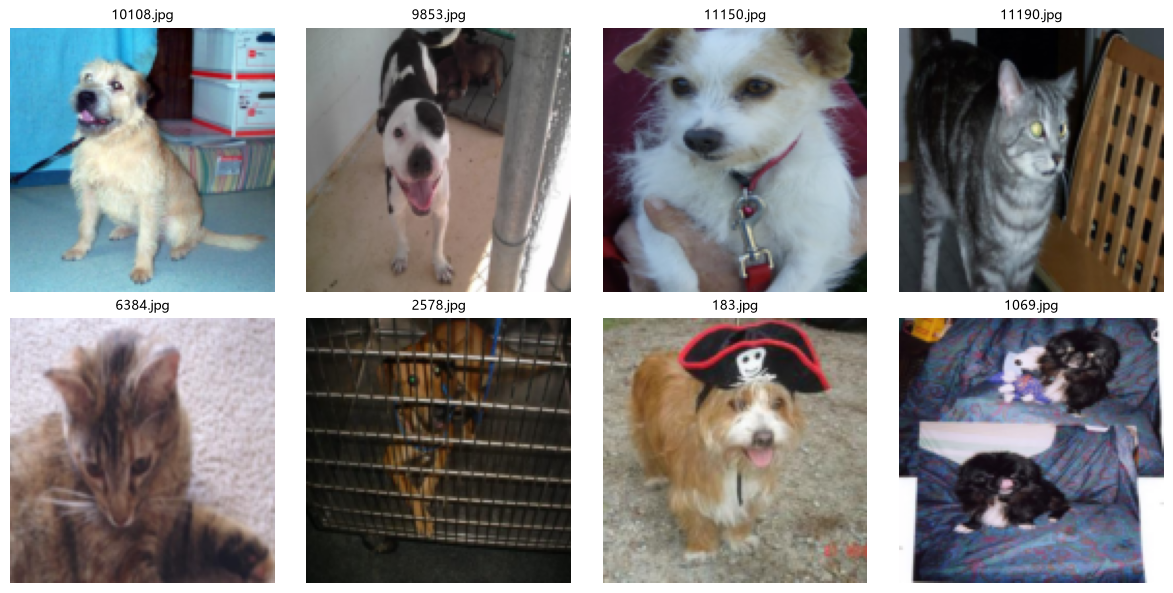

In [17]:
DATA_DIR = os.path.expanduser("~/datasets/PetImages")
BAD_FILES = {"Cat/666.jpg", "Dog/11702.jpg"}
files = []
for sub in ["Cat", "Dog"]:
    fs = sorted(glob.glob(os.path.join(DATA_DIR, sub, "*.jpg")))
    files += [f for f in fs if os.path.relpath(f, DATA_DIR) not in BAD_FILES]
random.seed(0)
batch_paths = random.sample(files, 8)
IMG_SIZE = 128
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.240, 0.225]
tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])
imgs = torch.stack([tf(Image.open(p).convert("RGB")) for p in batch_paths]).to(device)
print("batch:", imgs.shape)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    show = imgs[i].cpu() * torch.tensor(STD).view(3, 1, 1) + torch.tensor(MEAN).view(3, 1, 1)
    ax.imshow(show.clamp(0, 1).permute(1, 2, 0))
    ax.set_title(os.path.basename(batch_paths[i]), fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. 用 hook 抓取第一层和最后一层的特征图

- 第一层卷积：`model.conv1`（7×7、stride=2）
- 最后一层卷积：`model.layer4[1].conv2`（3×3）

`register_forward_hook` 的用法：给某个层挂一个回调，它前向算完就把输出存下来，不用改模型代码。

In [18]:
feats = {}
def make_hook(name):
    def fn(module, inp, out):
        feats[name] = out.detach()
    return fn
h1 = model.conv1.register_forward_hook(make_hook("first"))
h2 = model.layer4[1].conv2.register_forward_hook(make_hook("last"))
with torch.no_grad():
    logits = model(imgs)
h1.remove()
h2.remove()
print("conv1 输出:", tuple(feats["first"].shape))
print("layer4[1].conv2 输出:", tuple(feats["last"].shape))
print("分类 logits:", tuple(logits.shape))

conv1 输出: (8, 64, 64, 64)
layer4[1].conv2 输出: (8, 512, 4, 4)
分类 logits: (8, 1000)


## 4. 沿 H×W 算 L2 范数：b×c×h×w → b×c

每个通道整张特征图平方求和再开根号，得到"这个通道对这张图的响应强度"。

In [19]:
norm_first = feats["first"].norm(dim=[2, 3])
norm_last = feats["last"].norm(dim=[2, 3])
print("第一层:", tuple(norm_first.shape), "| 最后一层:", tuple(norm_last.shape))
print()
print("图1 第一层 64 个通道的 L2（前 10 个）:")
print(norm_first[0, :10].cpu())
print("图1 最后一层 512 个通道的 L2（前 10 个）:")
print(norm_last[0, :10].cpu())

第一层: (8, 64) | 最后一层: (8, 512)

图1 第一层 64 个通道的 L2（前 10 个）:
tensor([5.6979e+01, 1.2410e+02, 4.6958e-04, 9.1091e+01, 2.0811e-05, 9.9929e+01,
        7.5161e+01, 1.2872e-04, 4.6219e+01, 3.8301e-03])
图1 最后一层 512 个通道的 L2（前 10 个）:
tensor([0.3238, 0.7087, 0.6741, 0.4554, 1.1167, 0.6034, 0.2791, 0.3477, 0.3452,
        1.1281])


## 5. 可视化对比

图1：第一层 64 个通道的 L2 柱状图 vs 最后一层 512 个通道的 L2（降序排列）。
图2：每张图"活跃通道"占比——L2 超过该图最大值 10% 的通道数 / 总通道数。

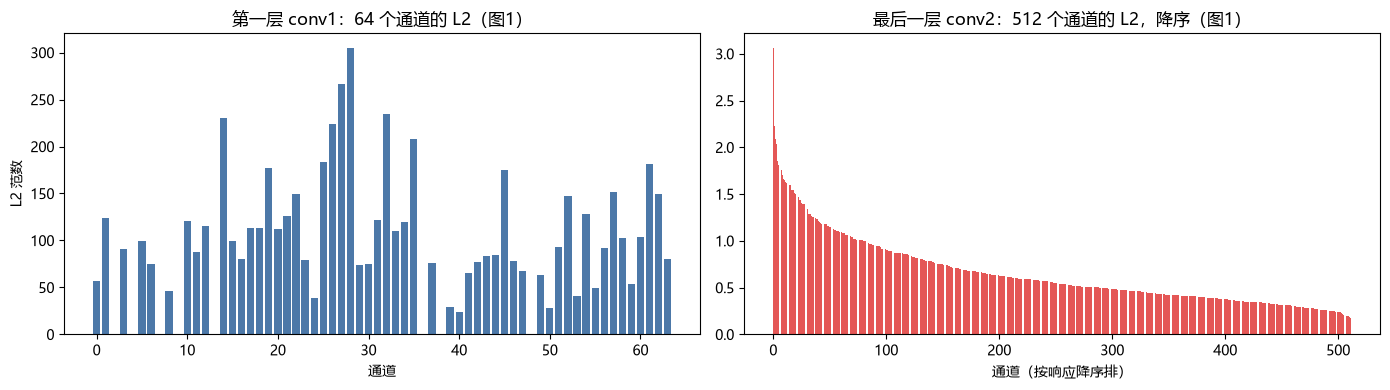

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(64), norm_first[0].cpu(), color="#4C78A8")
axes[0].set_title("第一层 conv1：64 个通道的 L2（图1）")
axes[0].set_xlabel("通道")
axes[0].set_ylabel("L2 范数")
srt, _ = norm_last[0].sort(descending=True)
axes[1].bar(range(512), srt.cpu(), color="#E45756")
axes[1].set_title("最后一层 conv2：512 个通道的 L2，降序（图1）")
axes[1].set_xlabel("通道（按响应降序排）")
plt.tight_layout()
plt.show()

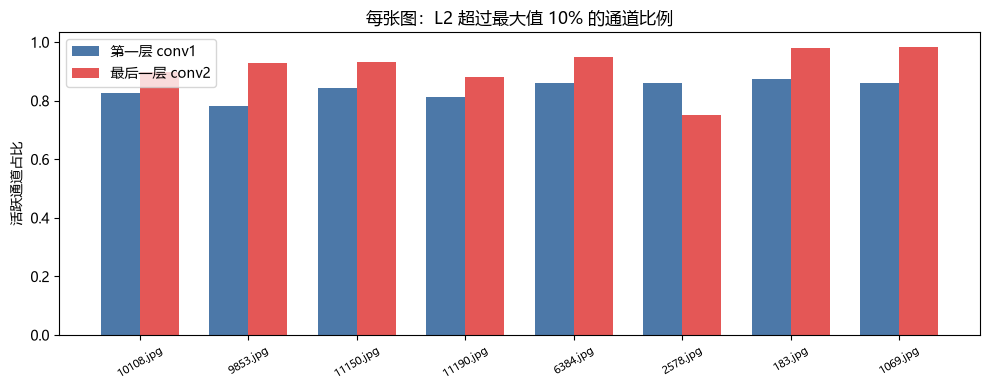

8 张图平均活跃占比  第一层: 84.0% | 最后一层: 91.3%


In [21]:
ratio_first = (norm_first > 0.1 * norm_first.max(dim=1, keepdim=True).values).float().mean(dim=1)
ratio_last = (norm_last > 0.1 * norm_last.max(dim=1, keepdim=True).values).float().mean(dim=1)
x = torch.arange(8)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.18, ratio_first.cpu(), width=0.36, label="第一层 conv1", color="#4C78A8")
ax.bar(x + 0.18, ratio_last.cpu(), width=0.36, label="最后一层 conv2", color="#E45756")
ax.set_xticks(x)
ax.set_xticklabels([os.path.basename(p)[:10] for p in batch_paths], rotation=30, fontsize=8)
ax.set_ylabel("活跃通道占比")
ax.set_title("每张图：L2 超过最大值 10% 的通道比例")
ax.legend()
plt.tight_layout()
plt.show()
print("8 张图平均活跃占比  第一层: {:.1%} | 最后一层: {:.1%}".format(
    ratio_first.mean().item(), ratio_last.mean().item()))

## 6. 观察与解释（看完图回答这三个问题）

1. 第一层是不是几乎**每个通道**都有响应？响应的通道集合在不同图片之间像不像？
2. 最后一层是不是只有**少数通道**响应强，大部分通道接近 0？
3. 不同图片在最后一层激活的通道**集合**是不是明显不一样？

提示：把你在这题看到的，和正餐第 5 步自己网络的特征图观察联系起来——浅层学边缘纹理、深层学语义组合，这个规律在 ImageNet 预训练的大网络里被放得更大。

# 扩展题3：Bottleneck 改造实验

把正餐 CNN 里的普通卷积块（单个 3×3 卷积）换成 **Bottleneck 结构（1×1 → 3×3 → 1×1）**，
在完全相同的条件下对比两个网络的**参数量、训练速度、分类精度**。

- 原版块：`Conv3x3(进→出) → ReLU → MaxPool`
- Bottleneck 块：`Conv1x1(降通道) → ReLU → Conv3x3(不变) → ReLU → Conv1x1(升通道) → ReLU → MaxPool`
- 两个网络的池化节奏（128→64→32→16）和分类器（16384→128→1）完全一致，只换卷积块，保证公平对照
- 真正 ResNet 的 Bottleneck 还带 BatchNorm 和残差捷径，这里先去掉，只看"1×1 夹 3×3"本身的账


## 1. 数据加载（与正餐完全同口径）

80/10/10 切分、seed=42、训练集用数据增强（和正餐增强版一致），保证与 0.8920 的基线可比。


In [33]:
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torchvision import transforms as T
class CatsDogsDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), 1.0 if "Dog" in self.paths[idx] else 0.0
labels = [1.0 if "Dog" in f else 0.0 for f in files]
full_ds = CatsDogsDataset(files, tf)
aug_tf = T.Compose([
    T.Resize(144),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(0.2, 0.2, 0.2),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])
g = torch.Generator().manual_seed(42)
n = len(full_ds)
n_train, n_val = int(n * 0.8), int(n * 0.1)
idx = torch.randperm(n, generator=g).tolist()
train_files = [files[i] for i in idx[:n_train]]
val_files = [files[i] for i in idx[n_train:n_train + n_val]]
test_files = [files[i] for i in idx[n_train + n_val:]]
train_ds = CatsDogsDataset(train_files, aug_tf)
val_ds = CatsDogsDataset(val_files, tf)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,
                           num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False,
                        num_workers=4, pin_memory=True, persistent_workers=True)
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_files)}")


train=19998  val=2499  test=2501


## 2. 两个模型：原版块 vs Bottleneck 块

In [34]:
class CatsDogsCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.classifier(self.features(x))
class BottleneckBlock(nn.Module):
    def __init__(self, c_in, c_mid, c_out):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(c_in, c_mid, 1), nn.ReLU(),
            nn.Conv2d(c_mid, c_mid, 3, padding=1), nn.ReLU(),
            nn.Conv2d(c_mid, c_out, 1), nn.ReLU(),
        )
        self.pool = nn.MaxPool2d(2)
    def forward(self, x):
        return self.pool(self.block(x))
class CatsDogsBottleneck(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            BottleneckBlock(3, 8, 16),
            BottleneckBlock(16, 16, 32),
            BottleneckBlock(32, 32, 64),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.classifier(self.features(x))
model_orig = CatsDogsCNN().to(device)
model_bt = CatsDogsBottleneck().to(device)


In [35]:
p_orig = sum(p.numel() for p in model_orig.parameters())
p_bt = sum(p.numel() for p in model_bt.parameters())
conv_orig = sum(p.numel() for m in model_orig.features if isinstance(m, nn.Conv2d) for p in m.parameters())
conv_bt = sum(p.numel() for m in model_bt.modules() if isinstance(m, nn.Conv2d) for p in m.parameters())
print(f"{'网络':<18}{'总参数量':>12}{'卷积部分':>12}{'全连接部分':>12}")
print(f"{'原版(3x3)':<18}{p_orig:>12,}{conv_orig:>12,}{p_orig - conv_orig:>12,}")
print(f"{'Bottleneck':<18}{p_bt:>12,}{conv_bt:>12,}{p_bt - conv_bt:>12,}")
print(f"\n卷积参数量变化: {conv_bt / conv_orig:.2%}")


网络                        总参数量        卷积部分       全连接部分
原版(3x3)              2,120,993      23,584   2,097,409
Bottleneck           2,113,721      16,312   2,097,409

卷积参数量变化: 69.17%


## 3. 训练函数（带计时，两边完全同条件）

In [36]:
def train_model(model, name, epochs=12, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "epoch_time": []}
    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True).float().view(-1, 1)
            loss = criterion(model(xb), yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        torch.cuda.synchronize() if device.type == "cuda" else None
        dt = time.time() - t0
        history["epoch_time"].append(dt)
        model.eval()
        v_loss, correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True).float().view(-1, 1)
                logit = model(xb)
                v_loss += criterion(logit, yb).item() * xb.size(0)
                correct += ((torch.sigmoid(logit) > 0.5) == yb).sum().item()
        history["train_loss"].append(total_loss / len(train_ds))
        history["val_loss"].append(v_loss / len(val_ds))
        history["val_acc"].append(correct / len(val_ds))
        print(f"[{name}] epoch {epoch:2d}/{epochs}  train_loss={history['train_loss'][-1]:.4f}  "
              f"val_loss={history['val_loss'][-1]:.4f}  val_acc={history['val_acc'][-1]:.4f}  "
              f"({dt:.0f}s)")
    return history
import time
print("训练函数就绪")


训练函数就绪


## 4. 训练原版（12 轮，约十几分钟）

In [37]:
hist_orig = train_model(model_orig, "原版")


/home/yeji/ml-env/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


[原版] epoch  1/12  train_loss=0.6166  val_loss=0.5405  val_acc=0.7243  (27s)


/home/yeji/ml-env/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


[原版] epoch  2/12  train_loss=0.5192  val_loss=0.4736  val_acc=0.7743  (22s)
[原版] epoch  3/12  train_loss=0.4592  val_loss=0.4401  val_acc=0.7967  (18s)
[原版] epoch  4/12  train_loss=0.4296  val_loss=0.4236  val_acc=0.8083  (22s)


/home/yeji/ml-env/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


[原版] epoch  5/12  train_loss=0.4020  val_loss=0.3816  val_acc=0.8263  (22s)
[原版] epoch  6/12  train_loss=0.3778  val_loss=0.3830  val_acc=0.8239  (22s)
[原版] epoch  7/12  train_loss=0.3639  val_loss=0.3535  val_acc=0.8439  (22s)
[原版] epoch  8/12  train_loss=0.3437  val_loss=0.3893  val_acc=0.8295  (22s)
[原版] epoch  9/12  train_loss=0.3262  val_loss=0.3848  val_acc=0.8263  (22s)
[原版] epoch 10/12  train_loss=0.3204  val_loss=0.3773  val_acc=0.8235  (22s)
[原版] epoch 11/12  train_loss=0.3033  val_loss=0.3899  val_acc=0.8271  (22s)
[原版] epoch 12/12  train_loss=0.2959  val_loss=0.3174  val_acc=0.8595  (23s)


/home/yeji/ml-env/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


## 5. 训练 Bottleneck 版（12 轮，同样条件）

In [38]:
hist_bt = train_model(model_bt, "Bottleneck")


[Bottleneck] epoch  1/12  train_loss=0.6940  val_loss=0.6936  val_acc=0.5070  (23s)
[Bottleneck] epoch  2/12  train_loss=0.6836  val_loss=0.6611  val_acc=0.6026  (23s)
[Bottleneck] epoch  3/12  train_loss=0.6520  val_loss=0.6166  val_acc=0.6495  (23s)
[Bottleneck] epoch  4/12  train_loss=0.5993  val_loss=0.5666  val_acc=0.6963  (23s)
[Bottleneck] epoch  5/12  train_loss=0.5620  val_loss=0.5457  val_acc=0.7231  (23s)
[Bottleneck] epoch  6/12  train_loss=0.5395  val_loss=0.5674  val_acc=0.7111  (23s)
[Bottleneck] epoch  7/12  train_loss=0.5146  val_loss=0.5218  val_acc=0.7347  (23s)
[Bottleneck] epoch  8/12  train_loss=0.5051  val_loss=0.5445  val_acc=0.7243  (23s)
[Bottleneck] epoch  9/12  train_loss=0.4943  val_loss=0.4859  val_acc=0.7731  (23s)
[Bottleneck] epoch 10/12  train_loss=0.4799  val_loss=0.5240  val_acc=0.7431  (23s)
[Bottleneck] epoch 11/12  train_loss=0.4736  val_loss=0.4585  val_acc=0.7759  (23s)
[Bottleneck] epoch 12/12  train_loss=0.4586  val_loss=0.4854  val_acc=0.7631

## 6. 三项对比：参数量 / 训练速度 / 精度

In [39]:
import numpy as np
def evaluate(model, files_):
    model.eval()
    ds = CatsDogsDataset(files_, tf)
    loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=4)
    correct = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = (torch.sigmoid(model(xb)) > 0.5).float().cpu()
            correct += (pred.view(-1) == yb).sum().item()
    return correct / len(ds)
test_orig = evaluate(model_orig, test_files)
test_bt = evaluate(model_bt, test_files)
print(f"{'指标':<12}{'原版':>14}{'Bottleneck':>14}")
print(f"{'参数量':<12}{p_orig:>14,}{p_bt:>14,}")
print(f"{'卷积参数量':<12}{conv_orig:>14,}{conv_bt:>14,}")
print(f"{'每轮耗时':>12}{np.mean(hist_orig['epoch_time']):>12.1f}s{np.mean(hist_bt['epoch_time']):>12.1f}s")
print(f"{'val acc峰值':<12}{max(hist_orig['val_acc']):>14.4f}{max(hist_bt['val_acc']):>14.4f}")
print(f"{'test acc':<12}{test_orig:>14.4f}{test_bt:>14.4f}")


指标                      原版    Bottleneck
参数量              2,120,993     2,113,721
卷积参数量               23,584        16,312
        每轮耗时        22.3s        22.7s
val acc峰值           0.8595        0.7759
test acc            0.8709        0.7737


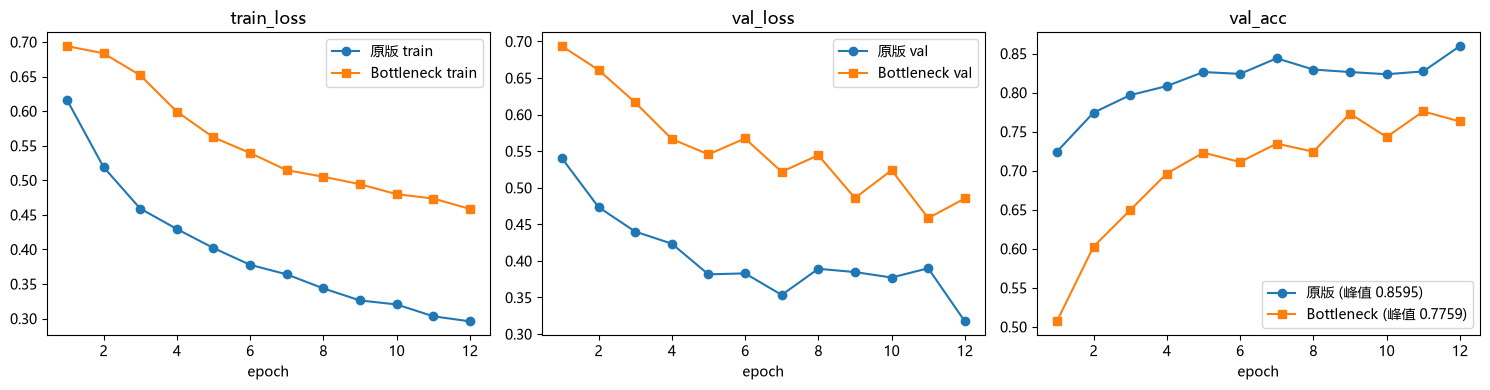

图已存为 bottleneck-compare.png


In [40]:
import numpy as np
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = range(1, 13)
axes[0].plot(epochs, hist_orig["train_loss"], "o-", label="原版 train")
axes[0].plot(epochs, hist_bt["train_loss"], "s-", label="Bottleneck train")
axes[0].set_title("train_loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(epochs, hist_orig["val_loss"], "o-", label="原版 val")
axes[1].plot(epochs, hist_bt["val_loss"], "s-", label="Bottleneck val")
axes[1].set_title("val_loss"); axes[1].set_xlabel("epoch"); axes[1].legend()
axes[2].plot(epochs, hist_orig["val_acc"], "o-", label=f"原版 (峰值 {max(hist_orig['val_acc']):.4f})")
axes[2].plot(epochs, hist_bt["val_acc"], "s-", label=f"Bottleneck (峰值 {max(hist_bt['val_acc']):.4f})")
axes[2].set_title("val_acc"); axes[2].set_xlabel("epoch"); axes[2].legend()
plt.tight_layout()
plt.savefig("bottleneck-compare.png", dpi=150, bbox_inches="tight")
plt.show()
print("图已存为 bottleneck-compare.png")


## 7. 观察与解释（跑完后回答）

1. Bottleneck 把卷积参数量变成了原来的百分之多少？总参数量为什么几乎没变？
2. 每轮训练耗时谁快谁慢？为什么？（提示：Bottleneck 的层数多了，GPU 要跑更多小算子）
3. 精度上谁高谁低？差距在什么量级？这和题目"Bottleneck 不一定提高小网络性能"的提示相符吗？


## 8. 复盘：Bottleneck 不是"没提升"，是"没学起来"

看上一节的数据：纯 Bottleneck 的 loss 十二轮钉死在 **0.6932 ≈ ln2**，val_acc ≈ 50%——这是二分类瞎猜的水平，
说明网络输出的 logit 恒定，**梯度根本没流动起来**。

原因：我们的 Bottleneck 块是"裸"的——**没有 BatchNorm、没有残差捷径**。
多出来的 1×1 卷积层让激活值的分布一路漂移、梯度一路衰减，信号传到分类器时已经"死"了。

而**真正 ResNet 里的 Bottleneck 是带着 BatchNorm 和残差捷径工作的**——这正是 ResNet 论文的核心贡献：
不是"1×1 夹 3×3 这个形状本身多厉害"，而是"配上了 BN + shortcut 之后，深层网络才训得动"。

下面做抢救实验：给 Bottleneck 块的每层卷积后面加 BatchNorm（还是不加残差，保持其他变量不动），看能不能救回来。


In [41]:
class BottleneckBNBlock(nn.Module):
    def __init__(self, c_in, c_mid, c_out):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(c_in, c_mid, 1, bias=False), nn.BatchNorm2d(c_mid), nn.ReLU(),
            nn.Conv2d(c_mid, c_mid, 3, padding=1, bias=False), nn.BatchNorm2d(c_mid), nn.ReLU(),
            nn.Conv2d(c_mid, c_out, 1, bias=False), nn.BatchNorm2d(c_out), nn.ReLU(),
        )
        self.pool = nn.MaxPool2d(2)
    def forward(self, x):
        return self.pool(self.block(x))
class CatsDogsBottleneckBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            BottleneckBNBlock(3, 8, 16),
            BottleneckBNBlock(16, 16, 32),
            BottleneckBNBlock(32, 32, 64),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.classifier(self.features(x))
model_btn = CatsDogsBottleneckBN().to(device)
print("BottleneckBN 参数量:", sum(p.numel() for p in model_btn.parameters()))


BottleneckBN 参数量: 2113945


## 9. 训练 BottleneckBN（12 轮，约 5 分钟）

In [42]:
hist_btn = train_model(model_btn, "BN版")


[BN版] epoch  1/12  train_loss=0.6647  val_loss=0.5797  val_acc=0.6919  (23s)
[BN版] epoch  2/12  train_loss=0.5773  val_loss=0.5517  val_acc=0.7115  (23s)
[BN版] epoch  3/12  train_loss=0.5345  val_loss=0.5823  val_acc=0.7179  (23s)
[BN版] epoch  4/12  train_loss=0.4945  val_loss=0.5444  val_acc=0.7431  (23s)
[BN版] epoch  5/12  train_loss=0.4571  val_loss=0.6735  val_acc=0.6691  (23s)
[BN版] epoch  6/12  train_loss=0.4365  val_loss=0.4370  val_acc=0.7979  (23s)
[BN版] epoch  7/12  train_loss=0.4183  val_loss=0.6119  val_acc=0.7411  (23s)
[BN版] epoch  8/12  train_loss=0.3994  val_loss=0.4751  val_acc=0.7823  (23s)
[BN版] epoch  9/12  train_loss=0.3886  val_loss=0.4119  val_acc=0.8239  (23s)
[BN版] epoch 10/12  train_loss=0.3746  val_loss=0.4757  val_acc=0.7967  (23s)
[BN版] epoch 11/12  train_loss=0.3640  val_loss=0.3910  val_acc=0.8239  (23s)
[BN版] epoch 12/12  train_loss=0.3484  val_loss=0.4172  val_acc=0.8135  (23s)


## 10. 三方对比：裸 Bottleneck vs +BN vs 原版

指标                    原版   裸Bottleneck   Bottleneck+BN
val acc峰值         0.8595        0.7759          0.8239
test acc          0.8709        0.7737          0.8253


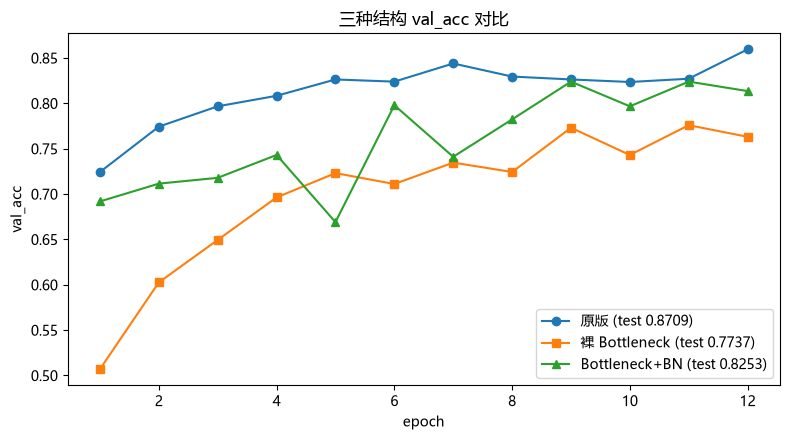

图已存为 bottleneck-bn-compare.png


In [43]:
test_btn = evaluate(model_btn, test_files)
print(f"{'指标':<12}{'原版':>12}{'裸Bottleneck':>14}{'Bottleneck+BN':>16}")
print(f"{'val acc峰值':<12}{max(hist_orig['val_acc']):>12.4f}{max(hist_bt['val_acc']):>14.4f}{max(hist_btn['val_acc']):>16.4f}")
print(f"{'test acc':<12}{test_orig:>12.4f}{test_bt:>14.4f}{test_btn:>16.4f}")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, 13), hist_orig["val_acc"], "o-", label=f"原版 (test {test_orig:.4f})")
ax.plot(range(1, 13), hist_bt["val_acc"], "s-", label=f"裸 Bottleneck (test {test_bt:.4f})")
ax.plot(range(1, 13), hist_btn["val_acc"], "^-", label=f"Bottleneck+BN (test {test_btn:.4f})")
ax.set_xlabel("epoch"); ax.set_ylabel("val_acc"); ax.set_title("三种结构 val_acc 对比")
ax.legend(); plt.tight_layout()
plt.savefig("bottleneck-bn-compare.png", dpi=150, bbox_inches="tight")
plt.show()
print("图已存为 bottleneck-bn-compare.png")


## 11. 抢救实验观察（跑完回答）

1. 加了 BN 之后 Bottleneck 能正常学习了吗？精度回到什么水平？
2. 结合这次和上次的对照，说明 1×1→3×3→1×1 这个形状本身是不是问题所在？真正缺的是什么？
3. 回头看 ResNet 论文的两大贡献（残差捷径 + BatchNorm），你觉得哪一个在这场"抢救"里功劳更大？


# 扩展题4：手搓 ResNet-18

不调用 `torchvision.models`，从零实现 ResNet-18 的主要架构，跑一个 batch 验证形状，
并画一张简化结构图。

ResNet-18 的核心组件（题目不允许抄现成的，那就自己搭）：

- **Stem**：7×7 卷积（stride 2）→ BN → ReLU → 3×3 MaxPool（stride 2），尺寸 224 → 112 → 56
- **4 个 stage**（layer1~layer4）：每个 stage 由 **2 个 BasicBlock** 组成，通道 64 → 128 → 256 → 512
  - BasicBlock：`3×3卷积 → BN → ReLU → 3×3卷积 → BN`，输出与输入**相加**后再 ReLU——这就是残差捷径
  - 每个 stage 的第一个 block 用 stride=2 下采样（layer1 除外），捷径里配 1×1 卷积对齐通道
- **收尾**：全局平均池化（GAP）→ 全连接层，任意输入尺寸都能跑通


In [44]:
class BasicBlock(nn.Module):
    def __init__(self, c_in, c_out, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(c_in, c_out, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c_out)
        self.conv2 = nn.Conv2d(c_out, c_out, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c_out)
        self.relu = nn.ReLU(inplace=True)
        if stride != 1 or c_in != c_out:
            self.shortcut = nn.Sequential(
                nn.Conv2d(c_in, c_out, 1, stride=stride, bias=False),
                nn.BatchNorm2d(c_out),
            )
        else:
            self.shortcut = nn.Identity()
    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return self.relu(out)
class MyResNet18(nn.Module):
    def __init__(self, num_classes=1000):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
        )
        self.layer1 = nn.Sequential(BasicBlock(64, 64), BasicBlock(64, 64))
        self.layer2 = nn.Sequential(BasicBlock(64, 128, stride=2), BasicBlock(128, 128))
        self.layer3 = nn.Sequential(BasicBlock(128, 256, stride=2), BasicBlock(256, 256))
        self.layer4 = nn.Sequential(BasicBlock(256, 512, stride=2), BasicBlock(512, 512))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512, num_classes)
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)
print("MyResNet18 定义完成")


MyResNet18 定义完成


## 跑一个 batch 验证形状

用随机张量模拟 batch=4 的 ImageNet 输入（3×224×224），同时追踪中间特征图尺寸，
对照 ResNet-18 论文：224 → 112 → 56 → 56 → 28 → 14 → 7 → GAP → 512 → 1000。


In [45]:
my_resnet = MyResNet18().to(device)
x = torch.randn(4, 3, 224, 224).to(device)
acts = {}
def hook(name):
    def fn(m, i, o):
        acts[name] = o.shape
    return fn
my_resnet.stem.register_forward_hook(hook("stem"))
my_resnet.layer1.register_forward_hook(hook("layer1"))
my_resnet.layer2.register_forward_hook(hook("layer2"))
my_resnet.layer3.register_forward_hook(hook("layer3"))
my_resnet.layer4.register_forward_hook(hook("layer4"))
my_resnet.eval()
with torch.no_grad():
    out = my_resnet(x)
n_params = sum(p.numel() for p in my_resnet.parameters())
print(f"输入: {tuple(x.shape)}")
for name in ["stem", "layer1", "layer2", "layer3", "layer4"]:
    print(f"{name:<7} 输出: {tuple(acts[name])}")
print(f"最终输出: {tuple(out.shape)}   (batch=4, 1000类)")
print(f"总参数量: {n_params:,}  （论文 ResNet-18: 11.69M）")


输入: (4, 3, 224, 224)
stem    输出: (4, 64, 56, 56)
layer1  输出: (4, 64, 56, 56)
layer2  输出: (4, 128, 28, 28)
layer3  输出: (4, 256, 14, 14)
layer4  输出: (4, 512, 7, 7)
最终输出: (4, 1000)   (batch=4, 1000类)
总参数量: 11,689,512  （论文 ResNet-18: 11.69M）


## 换小尺寸输入验证 GAP 的作用

全局平均池化让网络不挑输入尺寸——64×64 的小图也能直接跑。


In [46]:
x_small = torch.randn(2, 3, 64, 64).to(device)
with torch.no_grad():
    out_small = my_resnet(x_small)
print(f"输入 {tuple(x_small.shape)} → 输出 {tuple(out_small.shape)}，任意尺寸输入都 OK")


输入 (2, 3, 64, 64) → 输出 (2, 1000)，任意尺寸输入都 OK


## 简化结构图

左半是整体流水线（4 个 stage 的尺寸/通道变化），右半是 BasicBlock 内部结构，重点画出残差捷径。


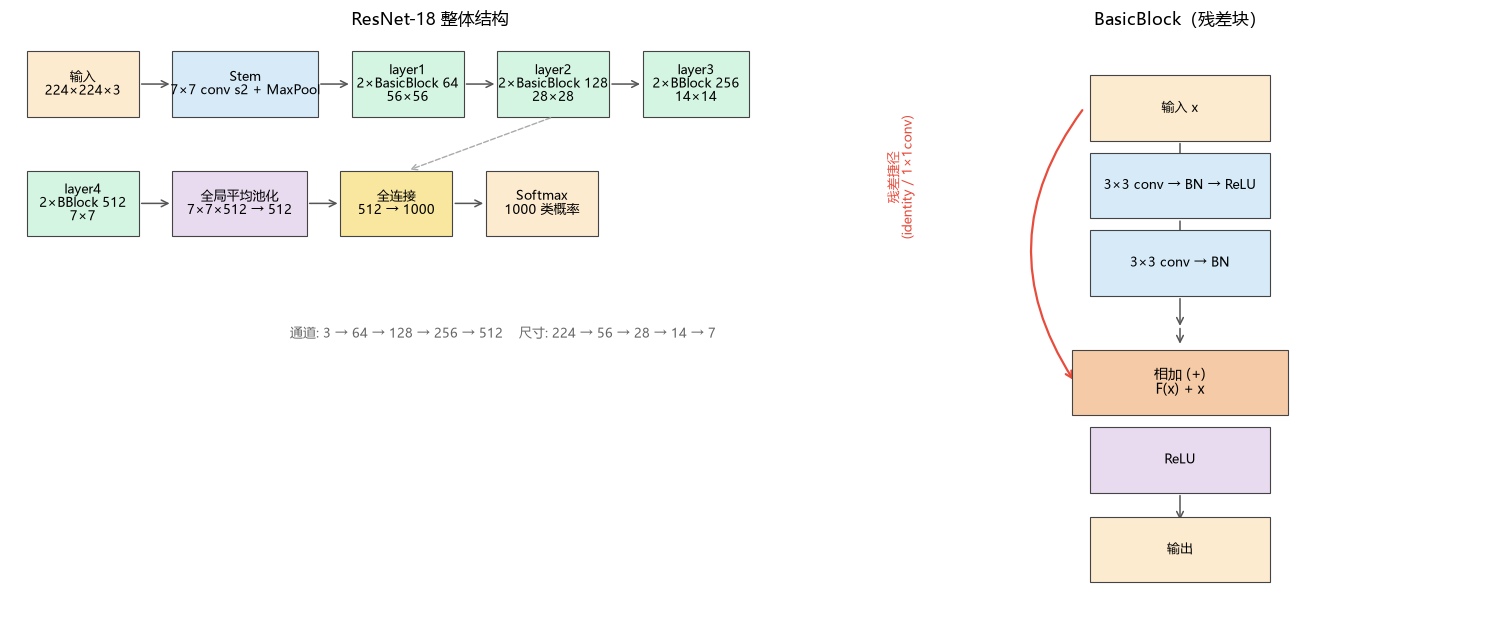

图已存为 resnet18-diagram.png


In [47]:
from matplotlib.patches import FancyArrowPatch
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), width_ratios=[1.4, 1])
def box(ax, x, y, w, h, text, fc, fontsize=9):
    r = plt.Rectangle((x, y), w, h, fc=fc, ec="#444444", lw=0.8, zorder=2)
    ax.add_patch(r)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize, zorder=3)
def arrow(ax, x1, y1, x2, y2, color="#555555"):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="->",
                                  mutation_scale=12, color=color, lw=1.1, zorder=1))
ax1.set_xlim(0, 15); ax1.set_ylim(0, 10); ax1.axis("off")
ax1.set_title("ResNet-18 整体结构", fontsize=12)
y = 8.6; h = 1.1
box(ax1, 0.3, y, 2.0, h, "输入\n224×224×3", "#FDEBD0")
arrow(ax1, 2.3, y + h / 2, 2.9, y + h / 2)
box(ax1, 2.9, y, 2.6, h, "Stem\n7×7 conv s2 + MaxPool", "#D6EAF8")
arrow(ax1, 5.5, y + h / 2, 6.1, y + h / 2)
box(ax1, 6.1, y, 2.0, h, "layer1\n2×BasicBlock 64\n56×56", "#D5F5E3")
arrow(ax1, 8.1, y + h / 2, 8.7, y + h / 2)
box(ax1, 8.7, y, 2.0, h, "layer2\n2×BasicBlock 128\n28×28", "#D5F5E3")
arrow(ax1, 10.7, y + h / 2, 11.3, y + h / 2)
box(ax1, 11.3, y, 1.9, h, "layer3\n2×BBlock 256\n14×14", "#D5F5E3")
y = 6.6
box(ax1, 0.3, y, 2.0, h, "layer4\n2×BBlock 512\n7×7", "#D5F5E3")
arrow(ax1, 2.3, y + h / 2, 2.9, y + h / 2)
box(ax1, 2.9, y, 2.4, h, "全局平均池化\n7×7×512 → 512", "#E8DAEF")
arrow(ax1, 5.3, y + h / 2, 5.9, y + h / 2)
box(ax1, 5.9, y, 2.0, h, "全连接\n512 → 1000", "#F9E79F")
arrow(ax1, 7.9, y + h / 2, 8.5, y + h / 2)
box(ax1, 8.5, y, 2.0, h, "Softmax\n1000 类概率", "#FDEBD0")
ax1.annotate("", xy=(7.1, 7.7), xytext=(9.7, 8.6),
             arrowprops=dict(arrowstyle="->", color="#AAAAAA", lw=1, ls="--"))
ax1.text(5.0, 4.9, "通道: 3 → 64 → 128 → 256 → 512    尺寸: 224 → 56 → 28 → 14 → 7",
         fontsize=9, color="#666666")
ax2.set_xlim(0, 10); ax2.set_ylim(0, 10); ax2.axis("off")
ax2.set_title("BasicBlock（残差块）", fontsize=12)
y = 8.2
box(ax2, 3.5, y, 3.0, h, "输入 x", "#FDEBD0")
arrow(ax2, 5.0, y, 5.0, y - 0.5)
y = 6.9
box(ax2, 3.5, y, 3.0, h, "3×3 conv → BN → ReLU", "#D6EAF8")
arrow(ax2, 5.0, y, 5.0, y - 0.5)
y = 5.6
box(ax2, 3.5, y, 3.0, h, "3×3 conv → BN", "#D6EAF8")
arrow(ax2, 5.0, y, 5.0, y - 0.55)
box(ax2, 3.2, 3.6, 3.6, h, "相加 (+)\nF(x) + x", "#F5CBA7", fontsize=10)
arrow(ax2, 5.0, 5.1, 5.0, 4.75)
y = 2.3
box(ax2, 3.5, y, 3.0, h, "ReLU", "#E8DAEF")
arrow(ax2, 5.0, y, 5.0, y - 0.5)
box(ax2, 3.5, 0.8, 3.0, h, "输出", "#FDEBD0")
ax2.add_patch(FancyArrowPatch((3.4, 8.75), (3.25, 4.15),
                              connectionstyle="arc3,rad=0.35", arrowstyle="->",
                              mutation_scale=12, color="#E74C3C", lw=1.6))
ax2.text(0.35, 6.6, "残差捷径\n(identity / 1×1conv)", fontsize=9, color="#E74C3C",
         ha="center", rotation=90)
plt.tight_layout()
plt.savefig("resnet18-diagram.png", dpi=150, bbox_inches="tight")
plt.show()
print("图已存为 resnet18-diagram.png")


## 观察与解释（跑完回答）

1. 你的手搓版参数量是多少？和论文的 11.69M 对得上吗（误差多少）？
2. 追踪的中间尺寸链 224 → 112 → 56 → 56 → 28 → 14 → 14 → 7 里，哪两次下采样来自 stem？哪四次来自 BasicBlock 的 stride？
3. 残差捷径 `out + self.shortcut(x)` 到底解决什么问题？结合扩展题3的实验（裸 Bottleneck 训不动）说说：如果这个 18 层网络去掉所有捷径，你预计会发生什么？
